# Taller Práctico 2

cesar mora,

johan garcia

###  Instrucciones
1. Activa la GPU: **Entorno de ejecución → Cambiar tipo de entorno → T4 GPU**
2. subir video a colab
3. guardarlo como video.mp4
4. Ejecuta todo
5. Los 5 videos filtrados se guardan automáticamente en  en una carpeta nueva

In [5]:
# ══════════════════════════════════════════════════════════
#  CELDA 1 — Verificar GPU
# ══════════════════════════════════════════════════════════
!nvidia-smi | head -20

Sun Mar  8 00:59:49 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   48C    P8             14W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [7]:

# Ruta de tu video en Google Drive
VIDEO_PATH  = '/content/video.mp4'

# Carpeta donde se guardarán los 5 videos resultantes
OUTPUT_DIR  = '/content/TallerCUDA_Resultados'

# Parámetros ajustables de los filtros
BLUR_RADIUS = 3      # Filtro 2: radio del blur (1=3x3, 2=5x5, 3=7x7)
CROP_X      = 50     # Filtro 3: fila de inicio del recorte
CROP_Y      = 80     # Filtro 3: columna de inicio del recorte
CROP_W      = 640    # Filtro 3: ancho del recorte en píxeles
CROP_H      = 360    # Filtro 3: alto del recorte en píxeles
THRESHOLD   = 128    # Filtro 4: umbral de binarización (0-255)

# ══════════════════════════════════════════════════════════
import os, math, shutil
import numpy as np
import cv2
from numba import cuda
import matplotlib.pyplot as plt

os.makedirs(OUTPUT_DIR, exist_ok=True)

assert os.path.exists(VIDEO_PATH), (
    f' No se encontró el video en: {VIDEO_PATH}\n'
    f'   Asegúrate de subir tu video a esta ruta en el explorador de archivos de Colab.'
)
print(f' Video encontrado : {VIDEO_PATH}')
print(f' Carpeta de salida: {OUTPUT_DIR}')

✅ Video encontrado : /content/video.mp4
✅ Carpeta de salida: /content/TallerCUDA_Resultados


In [8]:
# ══════════════════════════════════════════════════════════
#  CELDA 4 — Kernels CUDA
# ══════════════════════════════════════════════════════════

# ── Filtro 1: Inversión de Colores (Negativo) ─────────────
# Operación puntual: canal_out = 255 - canal_in
@cuda.jit
def kernel_invert(img_in, img_out):
    i, j = cuda.grid(2)
    rows, cols, channels = img_in.shape
    if i < rows and j < cols:
        for c in range(channels):
            img_out[i, j, c] = 255 - img_in[i, j, c]

# ── Filtro 2: Blur (Box Filter) ────────────────────────────
# Convolución NxN: promedio de los vecinos en un radio r
@cuda.jit
def kernel_blur(img_in, img_out, radius):
    i, j = cuda.grid(2)
    rows, cols, channels = img_in.shape
    if i < rows and j < cols:
        kernel_size = (2 * radius + 1) * (2 * radius + 1)
        for c in range(channels):
            total = 0.0
            for m in range(-radius, radius + 1):
                for n in range(-radius, radius + 1):
                    ni = min(max(i + m, 0), rows - 1)
                    nj = min(max(j + n, 0), cols - 1)
                    total += img_in[ni, nj, c]
            img_out[i, j, c] = total / kernel_size

# ── Filtro 3: Recorte (Crop) ───────────────────────────────
# Mapeo: P_dest(i,j) = P_src(i+x_start, j+y_start)
@cuda.jit
def kernel_crop(img_in, img_out, x_start, y_start):
    i, j = cuda.grid(2)
    out_rows, out_cols, channels = img_out.shape
    in_rows, in_cols, _ = img_in.shape
    if i < out_rows and j < out_cols:
        si, sj = i + x_start, j + y_start
        for c in range(channels):
            img_out[i, j, c] = img_in[si, sj, c] if (si < in_rows and sj < in_cols) else 0

# ── Filtro 4: Binarización ─────────────────────────────────
# P_out = 255 si promedio(RGB) > T, sino 0
@cuda.jit
def kernel_binary(img_in, img_out, threshold):
    i, j = cuda.grid(2)
    rows, cols, _ = img_in.shape
    if i < rows and j < cols:
        intensity = (int(img_in[i, j, 0]) + int(img_in[i, j, 1]) + int(img_in[i, j, 2])) / 3
        val = 255 if intensity > threshold else 0
        img_out[i, j, 0] = val
        img_out[i, j, 1] = val
        img_out[i, j, 2] = val

# ── Filtro 5: Detección de Bordes Sobel ───────────────────
# Kx detecta bordes verticales, Ky horizontales
# Magnitud G = sqrt(Gx^2 + Gy^2)
@cuda.jit
def kernel_sobel(img_gray, img_out):
    i, j = cuda.grid(2)
    rows, cols = img_gray.shape
    if i < rows and j < cols:
        i0 = max(i - 1, 0);  i2 = min(i + 1, rows - 1)
        j0 = max(j - 1, 0);  j2 = min(j + 1, cols - 1)

        # Kernel Kx = [[-1,0,1],[-2,0,2],[-1,0,1]]
        Gx = (- float(img_gray[i0, j0]) + float(img_gray[i0, j2])
              - 2.0 * float(img_gray[i,  j0]) + 2.0 * float(img_gray[i,  j2])
              - float(img_gray[i2, j0]) + float(img_gray[i2, j2]))

        # Kernel Ky = [[-1,-2,-1],[0,0,0],[1,2,1]]
        Gy = (- float(img_gray[i0, j0]) - 2.0 * float(img_gray[i0, j]) - float(img_gray[i0, j2])
              + float(img_gray[i2, j0]) + 2.0 * float(img_gray[i2, j]) + float(img_gray[i2, j2]))

        G = min(math.sqrt(Gx * Gx + Gy * Gy), 255.0)
        img_out[i, j, 0] = G
        img_out[i, j, 1] = G
        img_out[i, j, 2] = G

print(' Kernels CUDA compilados')

✅ Kernels CUDA compilados


In [9]:
# ══════════════════════════════════════════════════════════
#  CELDA 5 — Funciones de aplicación por frame
# ══════════════════════════════════════════════════════════

TPB = (16, 16)  # Threads per block (16x16 = 256 hilos por bloque)

def grid(rows, cols):
    """Calcula la malla de bloques necesaria para cubrir toda la imagen."""
    return (math.ceil(rows / TPB[0]), math.ceil(cols / TPB[1]))

def apply_invert(frame):
    d_in  = cuda.to_device(frame)
    d_out = cuda.device_array_like(frame)
    kernel_invert[grid(*frame.shape[:2]), TPB](d_in, d_out)
    cuda.synchronize()
    return d_out.copy_to_host()

def apply_blur(frame, radius):
    d_in  = cuda.to_device(frame)
    d_out = cuda.device_array_like(frame)
    kernel_blur[grid(*frame.shape[:2]), TPB](d_in, d_out, radius)
    cuda.synchronize()
    return d_out.copy_to_host()

def apply_crop(frame, x_start, y_start, w, h):
    rows, cols, ch = frame.shape
    # Validación de límites para evitar accesos fuera de memoria en GPU
    x_start = max(0, min(x_start, rows - 1))
    y_start = max(0, min(y_start, cols - 1))
    h = min(h, rows - x_start)
    w = min(w, cols - y_start)
    d_in  = cuda.to_device(frame)
    d_out = cuda.device_array((h, w, ch), dtype=np.uint8)
    kernel_crop[grid(h, w), TPB](d_in, d_out, x_start, y_start)
    cuda.synchronize()
    return d_out.copy_to_host()

def apply_binary(frame, threshold):
    d_in  = cuda.to_device(frame)
    d_out = cuda.device_array_like(frame)
    kernel_binary[grid(*frame.shape[:2]), TPB](d_in, d_out, threshold)
    cuda.synchronize()
    return d_out.copy_to_host()

def apply_sobel(frame):
    # Convertir a escala de grises antes del kernel Sobel
    gray = ((frame[:,:,0].astype(np.float32) +
             frame[:,:,1].astype(np.float32) +
             frame[:,:,2].astype(np.float32)) / 3).astype(np.uint8)
    d_gray = cuda.to_device(gray)
    d_out  = cuda.device_array(frame.shape, dtype=np.float32)
    kernel_sobel[grid(*gray.shape), TPB](d_gray, d_out)
    cuda.synchronize()
    return d_out.copy_to_host().astype(np.uint8)

print(' Funciones de filtro listas')

✅ Funciones de filtro listas


In [10]:
# ══════════════════════════════════════════════════════════
#  CELDA 6 — Pipeline Split → CUDA → Join
# ══════════════════════════════════════════════════════════

def process_video(video_path, output_path, filter_fn, label):
    """
    Pipeline completo para un filtro:
      Paso 1 — Split: extrae cada frame y lo guarda en disco (evita saturar RAM)
      Paso 2 — CUDA : aplica el filtro frame a frame en la GPU
      Paso 3 — Join : reensambla los frames en un video .mp4
    """
    tmp_in  = '/tmp/frames_in'
    tmp_out = '/tmp/frames_out'
    os.makedirs(tmp_in,  exist_ok=True)
    os.makedirs(tmp_out, exist_ok=True)

    # ── Paso 1: Split ──────────────────────────────────────
    cap   = cv2.VideoCapture(video_path)
    fps   = cap.get(cv2.CAP_PROP_FPS)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    w_src = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h_src = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    print(f'\n[{label}]')
    print(f'  Video fuente : {w_src}x{h_src} | {fps:.1f} FPS | {total} frames')

    idx = 0
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        cv2.imwrite(f'{tmp_in}/f{idx:06d}.png', frame)
        idx += 1
    cap.release()
    print(f'  Split        : {idx} frames guardados en disco')

    # ── Paso 2: Filtro CUDA frame a frame ─────────────────
    frame_files = sorted(os.listdir(tmp_in))
    print(f'  Filtro CUDA  : procesando...', end=' ', flush=True)
    for i, fname in enumerate(frame_files):
        frame_bgr = cv2.imread(f'{tmp_in}/{fname}')
        frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB).astype(np.uint8)
        result    = filter_fn(frame_rgb)
        cv2.imwrite(f'{tmp_out}/{fname}', cv2.cvtColor(result, cv2.COLOR_RGB2BGR))
        if (i + 1) % 60 == 0:
            print(f'{i+1}/{total}...', end=' ', flush=True)
    print('done.')

    # ── Paso 3: Join ───────────────────────────────────────
    sample       = cv2.imread(f'{tmp_out}/{frame_files[0]}')
    h_out, w_out = sample.shape[:2]
    fourcc       = cv2.VideoWriter_fourcc(*'mp4v')
    writer       = cv2.VideoWriter(output_path, fourcc, fps, (w_out, h_out))
    for fname in sorted(os.listdir(tmp_out)):
        writer.write(cv2.imread(f'{tmp_out}/{fname}'))
    writer.release()
    print(f'  Join         : video {w_out}x{h_out} guardado')
    print(f'  ✅ {output_path}')

    # Limpiar temporales para liberar disco
    shutil.rmtree(tmp_in,  ignore_errors=True)
    shutil.rmtree(tmp_out, ignore_errors=True)

print(' Pipeline definido')

✅ Pipeline definido


In [11]:
# ══════════════════════════════════════════════════════════
#  CELDA 7 — 🚀 PROCESAR CON LOS 5 FILTROS
# ══════════════════════════════════════════════════════════

filtros = [
    (
        'filtro1_negativo.mp4',
        lambda f: apply_invert(f),
        'Filtro 1 — Inversión de Colores'
    ),
    (
        'filtro2_blur.mp4',
        lambda f: apply_blur(f, BLUR_RADIUS),
        f'Filtro 2 — Blur (radio={BLUR_RADIUS}, kernel {2*BLUR_RADIUS+1}x{2*BLUR_RADIUS+1})'
    ),
    (
        'filtro3_recorte.mp4',
        lambda f: apply_crop(f, CROP_X, CROP_Y, CROP_W, CROP_H),
        f'Filtro 3 — Recorte (inicio=({CROP_X},{CROP_Y}), tamaño={CROP_W}x{CROP_H})'
    ),
    (
        'filtro4_binario.mp4',
        lambda f: apply_binary(f, THRESHOLD),
        f'Filtro 4 — Binarización (T={THRESHOLD})'
    ),
    (
        'filtro5_sobel.mp4',
        lambda f: apply_sobel(f),
        'Filtro 5 — Detección de Bordes Sobel'
    ),
]

print('=' * 58)
print('   PROCESANDO VIDEO CON 5 FILTROS CUDA')
print('=' * 58)

for filename, fn, label in filtros:
    process_video(VIDEO_PATH, os.path.join(OUTPUT_DIR, filename), fn, label)

print('\n' + '=' * 58)
print('  ¡Todos los filtros aplicados!')
print(f'  Resultados en Google Drive:')
print(f'    {OUTPUT_DIR}')
for fname, _, label in filtros:
    print(f'    • {fname}')
print('=' * 58)

   PROCESANDO VIDEO CON 5 FILTROS CUDA

[Filtro 1 — Inversión de Colores]
  Video fuente : 720x1280 | 30.0 FPS | 258 frames
  Split        : 255 frames guardados en disco
  Filtro CUDA  : procesando... 60/258... 120/258... 180/258... 240/258... done.
  Join         : video 720x1280 guardado
  ✅ /content/TallerCUDA_Resultados/filtro1_negativo.mp4

[Filtro 2 — Blur (radio=3, kernel 7x7)]
  Video fuente : 720x1280 | 30.0 FPS | 258 frames
  Split        : 255 frames guardados en disco
  Filtro CUDA  : procesando... 60/258... 120/258... 180/258... 240/258... done.
  Join         : video 720x1280 guardado
  ✅ /content/TallerCUDA_Resultados/filtro2_blur.mp4

[Filtro 3 — Recorte (inicio=(50,80), tamaño=640x360)]
  Video fuente : 720x1280 | 30.0 FPS | 258 frames
  Split        : 255 frames guardados en disco
  Filtro CUDA  : procesando... 60/258... 120/258... 180/258... 240/258... done.
  Join         : video 640x360 guardado
  ✅ /content/TallerCUDA_Resultados/filtro3_recorte.mp4

[Filtro 4 — B

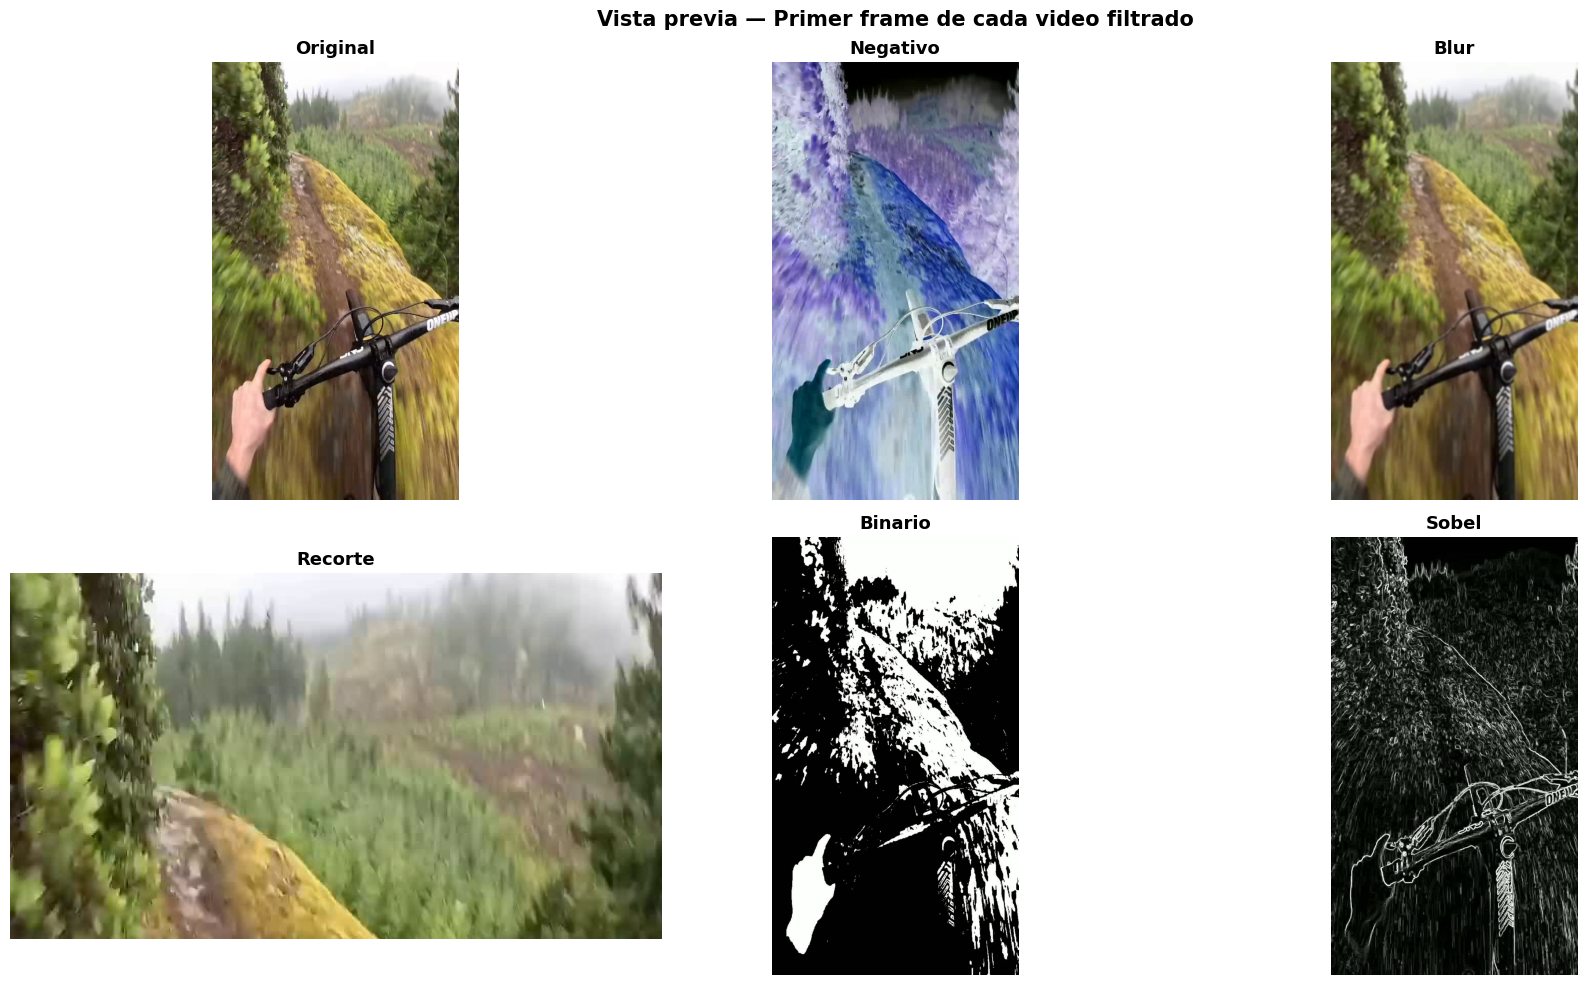

✅ Preview guardado en: /content/TallerCUDA_Resultados/preview_filtros.png


In [12]:
# ══════════════════════════════════════════════════════════
#  CELDA 8 — Vista previa: primer frame de cada video
# ══════════════════════════════════════════════════════════

resultados = [
    ('filtro1_negativo.mp4', 'Negativo'),
    ('filtro2_blur.mp4',     'Blur'),
    ('filtro3_recorte.mp4',  'Recorte'),
    ('filtro4_binario.mp4',  'Binario'),
    ('filtro5_sobel.mp4',    'Sobel'),
]

# Frame original
cap0 = cv2.VideoCapture(VIDEO_PATH)
ret0, frame0 = cap0.read()
cap0.release()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

axes[0].imshow(cv2.cvtColor(frame0, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original', fontsize=13, fontweight='bold')
axes[0].axis('off')

for ax, (fname, label) in zip(axes[1:], resultados):
    path = os.path.join(OUTPUT_DIR, fname)
    cap  = cv2.VideoCapture(path)
    ret, frame = cap.read()
    cap.release()
    if ret:
        ax.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        ax.set_title(label, fontsize=13, fontweight='bold')
    ax.axis('off')

plt.suptitle('Vista previa — Primer frame de cada video filtrado', fontsize=15, fontweight='bold')
plt.tight_layout()
preview_path = os.path.join(OUTPUT_DIR, 'preview_filtros.png')
plt.savefig(preview_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Preview guardado en: {preview_path}')